In [2]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json 
import warnings
warnings.filterwarnings("ignore")

In [3]:
df=pd.read_csv(r"E:\all resources sai krishna\ml project\train_v2.csv" ,nrows=100000)

In [4]:
df.shape

(100000, 13)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 13 columns):
 #   Column                Non-Null Count   Dtype 
---  ------                --------------   ----- 
 0   channelGrouping       100000 non-null  object
 1   customDimensions      100000 non-null  object
 2   date                  100000 non-null  int64 
 3   device                100000 non-null  object
 4   fullVisitorId         100000 non-null  object
 5   geoNetwork            100000 non-null  object
 6   hits                  100000 non-null  object
 7   socialEngagementType  100000 non-null  object
 8   totals                100000 non-null  object
 9   trafficSource         100000 non-null  object
 10  visitId               100000 non-null  int64 
 11  visitNumber           100000 non-null  int64 
 12  visitStartTime        100000 non-null  int64 
dtypes: int64(4), object(9)
memory usage: 9.9+ MB


In [6]:
df.head()

,channelGrouping,customDimensions,date,device,fullVisitorId,geoNetwork,hits,socialEngagementType,totals,trafficSource,visitId,visitNumber,visitStartTime
0,Organic Search,"[{'index': '4', 'value': 'EMEA'}]",20171016,"{""browser"": ""Firefox"", ""browserVersion"": ""not ...",3162355547410993243,"{""continent"": ""Europe"", ""subContinent"": ""Weste...","[{'hitNumber': '1', 'time': '0', 'hour': '17',...",Not Socially Engaged,"{""visits"": ""1"", ""hits"": ""1"", ""pageviews"": ""1"",...","{""campaign"": ""(not set)"", ""source"": ""google"", ...",1508198450,1,1508198450
1,Referral,"[{'index': '4', 'value': 'North America'}]",20171016,"{""browser"": ""Chrome"", ""browserVersion"": ""not a...",8934116514970143966,"{""continent"": ""Americas"", ""subContinent"": ""Nor...","[{'hitNumber': '1', 'time': '0', 'hour': '10',...",Not Socially Engaged,"{""visits"": ""1"", ""hits"": ""2"", ""pageviews"": ""2"",...","{""referralPath"": ""/a/google.com/transportation...",1508176307,6,1508176307
2,Direct,"[{'index': '4', 'value': 'North America'}]",20171016,"{""browser"": ""Chrome"", ""browserVersion"": ""not a...",7992466427990357681,"{""continent"": ""Americas"", ""subContinent"": ""Nor...","[{'hitNumber': '1', 'time': '0', 'hour': '17',...",Not Socially Engaged,"{""visits"": ""1"", ""hits"": ""2"", ""pageviews"": ""2"",...","{""campaign"": ""(not set)"", ""source"": ""(direct)""...",1508201613,1,1508201613
3,Organic Search,"[{'index': '4', 'value': 'EMEA'}]",20171016,"{""browser"": ""Chrome"", ""browserVersion"": ""not a...",9075655783635761930,"{""continent"": ""Asia"", ""subContinent"": ""Western...","[{'hitNumber': '1', 'time': '0', 'hour': '9', ...",Not Socially Engaged,"{""visits"": ""1"", ""hits"": ""2"", ""pageviews"": ""2"",...","{""campaign"": ""(not set)"", ""source"": ""google"", ...",1508169851,1,1508169851
4,Organic Search,"[{'index': '4', 'value': 'Central America'}]",20171016,"{""browser"": ""Chrome"", ""browserVersion"": ""not a...",6960673291025684308,"{""continent"": ""Americas"", ""subContinent"": ""Cen...","[{'hitNumber': '1', 'time': '0', 'hour': '14',...",Not Socially Engaged,"{""visits"": ""1"", ""hits"": ""2"", ""pageviews"": ""2"",...","{""campaign"": ""(not set)"", ""source"": ""google"", ...",1508190552,1,1508190552


In [7]:
df.drop(['hits','customDimensions'], axis=1,inplace=True)

In [8]:
for col in [ 'device' ,'geoNetwork', 'totals', 'trafficSource']:
           df[col]=df[col].apply(json.loads)

In [9]:
device_df=pd.json_normalize(df['device'])
geo_df=pd.json_normalize(df['geoNetwork'])
totals_df=pd.json_normalize(df['totals'])
traffic_df=pd.json_normalize(df['trafficSource'])

In [10]:
df=pd.concat([df,device_df,geo_df,totals_df,traffic_df],axis=1)

In [11]:
df.head()

,channelGrouping,date,device,fullVisitorId,geoNetwork,socialEngagementType,totals,trafficSource,visitId,visitNumber,...,keyword,adwordsClickInfo.criteriaParameters,referralPath,isTrueDirect,adContent,adwordsClickInfo.page,adwordsClickInfo.slot,adwordsClickInfo.gclId,adwordsClickInfo.adNetworkType,adwordsClickInfo.isVideoAd
0,Organic Search,20171016,"{'browser': 'Firefox', 'browserVersion': 'not ...",3162355547410993243,"{'continent': 'Europe', 'subContinent': 'Weste...",Not Socially Engaged,"{'visits': '1', 'hits': '1', 'pageviews': '1',...","{'campaign': '(not set)', 'source': 'google', ...",1508198450,1,...,water bottle,not available in demo dataset,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Referral,20171016,"{'browser': 'Chrome', 'browserVersion': 'not a...",8934116514970143966,"{'continent': 'Americas', 'subContinent': 'Nor...",Not Socially Engaged,"{'visits': '1', 'hits': '2', 'pageviews': '2',...",{'referralPath': '/a/google.com/transportation...,1508176307,6,...,NaN,not available in demo dataset,/a/google.com/transportation/mtv-services/bike...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Direct,20171016,"{'browser': 'Chrome', 'browserVersion': 'not a...",7992466427990357681,"{'continent': 'Americas', 'subContinent': 'Nor...",Not Socially Engaged,"{'visits': '1', 'hits': '2', 'pageviews': '2',...","{'campaign': '(not set)', 'source': '(direct)'...",1508201613,1,...,NaN,not available in demo dataset,NaN,True,NaN,NaN,NaN,NaN,NaN,NaN
3,Organic Search,20171016,"{'browser': 'Chrome', 'browserVersion': 'not a...",9075655783635761930,"{'continent': 'Asia', 'subContinent': 'Western...",Not Socially Engaged,"{'visits': '1', 'hits': '2', 'pageviews': '2',...","{'campaign': '(not set)', 'source': 'google', ...",1508169851,1,...,(not provided),not available in demo dataset,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Organic Search,20171016,"{'browser': 'Chrome', 'browserVersion': 'not a...",6960673291025684308,"{'continent': 'Americas', 'subContinent': 'Cen...",Not Socially Engaged,"{'visits': '1', 'hits': '2', 'pageviews': '2',...","{'campaign': '(not set)', 'source': 'google', ...",1508190552,1,...,(not provided),not available in demo dataset,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 61 columns):
 #   Column                               Non-Null Count   Dtype 
---  ------                               --------------   ----- 
 0   channelGrouping                      100000 non-null  object
 1   date                                 100000 non-null  int64 
 2   device                               100000 non-null  object
 3   fullVisitorId                        100000 non-null  object
 4   geoNetwork                           100000 non-null  object
 5   socialEngagementType                 100000 non-null  object
 6   totals                               100000 non-null  object
 7   trafficSource                        100000 non-null  object
 8   visitId                              100000 non-null  int64 
 9   visitNumber                          100000 non-null  int64 
 10  visitStartTime                       100000 non-null  int64 
 11  browser                    

In [13]:
print(df.columns)

Index(['channelGrouping', 'date', 'device', 'fullVisitorId', 'geoNetwork',
       'socialEngagementType', 'totals', 'trafficSource', 'visitId',
       'visitNumber', 'visitStartTime', 'browser', 'browserVersion',
       'browserSize', 'operatingSystem', 'operatingSystemVersion', 'isMobile',
       'mobileDeviceBranding', 'mobileDeviceModel', 'mobileInputSelector',
       'mobileDeviceInfo', 'mobileDeviceMarketingName', 'flashVersion',
       'language', 'screenColors', 'screenResolution', 'deviceCategory',
       'continent', 'subContinent', 'country', 'region', 'metro', 'city',
       'cityId', 'networkDomain', 'latitude', 'longitude', 'networkLocation',
       'visits', 'hits', 'pageviews', 'bounces', 'newVisits',
       'sessionQualityDim', 'timeOnSite', 'transactions', 'transactionRevenue',
       'totalTransactionRevenue', 'campaign', 'source', 'medium', 'keyword',
       'adwordsClickInfo.criteriaParameters', 'referralPath', 'isTrueDirect',
       'adContent', 'adwordsClickInfo.p

In [14]:
df.shape

(100000, 61)

MANUAL EDA

In [15]:
print(df.shape)
df.info()

(100000, 61)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 61 columns):
 #   Column                               Non-Null Count   Dtype 
---  ------                               --------------   ----- 
 0   channelGrouping                      100000 non-null  object
 1   date                                 100000 non-null  int64 
 2   device                               100000 non-null  object
 3   fullVisitorId                        100000 non-null  object
 4   geoNetwork                           100000 non-null  object
 5   socialEngagementType                 100000 non-null  object
 6   totals                               100000 non-null  object
 7   trafficSource                        100000 non-null  object
 8   visitId                              100000 non-null  int64 
 9   visitNumber                          100000 non-null  int64 
 10  visitStartTime                       100000 non-null  int64 
 11  browser       

In [16]:
missing = df.isnull().sum().sort_values(ascending=False)
missing.head(10)

totalTransactionRevenue           99003
transactionRevenue                99003
transactions                      98998
adContent                         96237
adwordsClickInfo.isVideoAd        95609
adwordsClickInfo.slot             95609
adwordsClickInfo.adNetworkType    95609
adwordsClickInfo.page             95609
adwordsClickInfo.gclId            95571
isTrueDirect                      69538
dtype: int64

In [17]:
(df["transactionRevenue"] > 0).sum()

TypeError: '>' not supported between instances of 'str' and 'int'

In [ ]:
## cleaning ###

cleaning

df.drop(['fullVisitorId','visitId'],axis=1,inplace=True)


In [ ]:
df.drop(['fullVisitorId','visitId'],axis=1,inplace=True)


In [ ]:
df.shape

(100000, 59)

missing value analysis

In [ ]:
df.isnull().sum().sort_values(ascending=True)

channelGrouping                       0
date                                  0
device                                0
fullVisitorId                         0
geoNetwork                            0
                                  ...  
adwordsClickInfo.adNetworkType    95609
adContent                         96237
transactions                      98998
transactionRevenue                99003
totalTransactionRevenue           99003
Length: 61, dtype: int64

In [ ]:
print(df.isnull().sum().sort_values(ascending=False))

totalTransactionRevenue                99003
transactionRevenue                     99003
transactions                           98998
adContent                              96237
adwordsClickInfo.adNetworkType         95609
adwordsClickInfo.page                  95609
adwordsClickInfo.isVideoAd             95609
adwordsClickInfo.slot                  95609
adwordsClickInfo.gclId                 95571
isTrueDirect                           69538
keyword                                69218
referralPath                           65843
sessionQualityDim                      53872
bounces                                50146
timeOnSite                             49974
newVisits                              23635
pageviews                                 11
date                                       0
channelGrouping                            0
geoNetwork                                 0
socialEngagementType                       0
totals                                     0
trafficSou

In [ ]:
behavior_cols=[
    'pageviews',
    'bounces',
    'newVisits',
    'timeOnSite',
    'transactions',
    'hits',
    'visits'
]

In [ ]:
df[behavior_cols]=df[behavior_cols].fillna(0)

In [ ]:
print(df.transactionRevenue)

0             NaN
1             NaN
2             NaN
3             NaN
4             NaN
           ...   
99995         NaN
99996    46380000
99997         NaN
99998    47990000
99999         NaN
Name: transactionRevenue, Length: 100000, dtype: object


In [ ]:
df['transactionRevenue']=pd.to_numeric(df['transactionRevenue'],errors='coerce')
df['totalTransactionRevenue']=pd.to_numeric(df['totalTransactionRevenue'],errors='coerce')

In [ ]:
df['transactionRevenue']=df['transactionRevenue'].fillna(0)
df['totalTransactionRevenue']=df['totalTransactionRevenue'].fillna(0)

In [ ]:
traffic_cols=[
    'keywords',
    'medium',
    'campaign',
    'source',
    'adContent',
    'referralPath'
]

In [ ]:
traffic_cols=[
    'keyword',
    'medium',
    'campaign',
    'source',
    'adContent',
    'referralPath'
]
    
df[traffic_cols]=df[traffic_cols].fillna("unknown")


In [ ]:
df.isnull().sum().sum()

np.int64(601417)

In [ ]:
ad_cols = [
    'adwordsClickInfo.page',
    'adwordsClickInfo.slot',
    'adwordsClickInfo.adNetworkType',
    'adwordsClickInfo.isVideoAd',
    'isTrueDirect'
]

for col in ad_cols:
    if col in df.columns:
        df[col] = df[col].fillna("unknown")

In [ ]:
df.fillna("unknown", inplace=True)

In [ ]:
df.isnull().sum().sum()

np.int64(0)

numerical colums
 pageviews

hits

visits

timeOnSite

transactions

transactionRevenue

totalTransactionRevenue

visitNumber




categorical columns

browser

deviceCategory

country

continent

source

medium

campaign

keyword



identiifer columns


fullVisitorId

visitId

cityId

time/date columns:
date

visitStartTime





behavioural columns
revenue columns 
traffic cloumns
ads columns

phase-7 (feature reduction)(smart columns removal)

In [ ]:
cols_drop=[
    'browserVersion',
    'browserSize',
    'mobileDeviceInfo',
    'mobileDeviceMarketingName',
    'mobileDeviceModel',
    'cityId',
    'latitude',
    'longitude',
    'networkLocation',
    'adwordsClickInfo.criteriaParameters'


]

In [ ]:
df.drop(cols_drop,axis=1,inplace=True)

In [ ]:
sparse_cols=[
    'adContent',
    'adwordsClickInfo.page',
    'adwordsClickInfo.slot',
    'adwordsClickInfo.adNetworkType',
    'adwordsClickInfo.isVideoAd'
]
df.drop(sparse_cols,axis=1,inplace=True)

In [ ]:
df.drop(columns=['totalTransactionRevenue'], inplace=True)

In [ ]:
df.shape

(100000, 43)

log transformation to compress data

In [ ]:
df['log_revenue']=np.log1p(df['transactionRevenue'])

In [ ]:
df.head()

,channelGrouping,date,device,geoNetwork,socialEngagementType,totals,trafficSource,visitNumber,visitStartTime,browser,...,transactions,transactionRevenue,campaign,source,medium,keyword,referralPath,isTrueDirect,adwordsClickInfo.gclId,log_revenue
0,Organic Search,20171016,"{'browser': 'Firefox', 'browserVersion': 'not ...","{'continent': 'Europe', 'subContinent': 'Weste...",Not Socially Engaged,"{'visits': '1', 'hits': '1', 'pageviews': '1',...","{'campaign': '(not set)', 'source': 'google', ...",1,1508198450,Firefox,...,0,0.0,(not set),google,organic,water bottle,unknown,unknown,unknown,0.0
1,Referral,20171016,"{'browser': 'Chrome', 'browserVersion': 'not a...","{'continent': 'Americas', 'subContinent': 'Nor...",Not Socially Engaged,"{'visits': '1', 'hits': '2', 'pageviews': '2',...",{'referralPath': '/a/google.com/transportation...,6,1508176307,Chrome,...,0,0.0,(not set),sites.google.com,referral,unknown,/a/google.com/transportation/mtv-services/bike...,unknown,unknown,0.0
2,Direct,20171016,"{'browser': 'Chrome', 'browserVersion': 'not a...","{'continent': 'Americas', 'subContinent': 'Nor...",Not Socially Engaged,"{'visits': '1', 'hits': '2', 'pageviews': '2',...","{'campaign': '(not set)', 'source': '(direct)'...",1,1508201613,Chrome,...,0,0.0,(not set),(direct),(none),unknown,unknown,True,unknown,0.0
3,Organic Search,20171016,"{'browser': 'Chrome', 'browserVersion': 'not a...","{'continent': 'Asia', 'subContinent': 'Western...",Not Socially Engaged,"{'visits': '1', 'hits': '2', 'pageviews': '2',...","{'campaign': '(not set)', 'source': 'google', ...",1,1508169851,Chrome,...,0,0.0,(not set),google,organic,(not provided),unknown,unknown,unknown,0.0
4,Organic Search,20171016,"{'browser': 'Chrome', 'browserVersion': 'not a...","{'continent': 'Americas', 'subContinent': 'Cen...",Not Socially Engaged,"{'visits': '1', 'hits': '2', 'pageviews': '2',...","{'campaign': '(not set)', 'source': 'google', ...",1,1508190552,Chrome,...,0,0.0,(not set),google,organic,(not provided),unknown,unknown,unknown,0.0


In [ ]:
cols_to_drop = [
'socialEngagementType',        # almost always "Not Socially Engaged"
'cityId',                      # redundant location id
'networkLocation',             # mostly unknown
'browserSize',                 # mostly empty
'browserVersion',              # too many unique values
'mobileDeviceInfo',            # high cardinality
'mobileDeviceMarketingName',
'mobileInputSelector',
'flashVersion',                # outdated feature
'screenColors',                # rarely useful
'sessionQualityDim'            # many missing values
]

df.drop(columns=cols_to_drop, inplace=True, errors='ignore')

In [ ]:
df.head()

,channelGrouping,date,device,geoNetwork,totals,trafficSource,visitNumber,visitStartTime,browser,operatingSystem,...,transactions,transactionRevenue,campaign,source,medium,keyword,referralPath,isTrueDirect,adwordsClickInfo.gclId,log_revenue
0,Organic Search,20171016,"{'browser': 'Firefox', 'browserVersion': 'not ...","{'continent': 'Europe', 'subContinent': 'Weste...","{'visits': '1', 'hits': '1', 'pageviews': '1',...","{'campaign': '(not set)', 'source': 'google', ...",1,1508198450,Firefox,Windows,...,0,0.0,(not set),google,organic,water bottle,unknown,unknown,unknown,0.0
1,Referral,20171016,"{'browser': 'Chrome', 'browserVersion': 'not a...","{'continent': 'Americas', 'subContinent': 'Nor...","{'visits': '1', 'hits': '2', 'pageviews': '2',...",{'referralPath': '/a/google.com/transportation...,6,1508176307,Chrome,Chrome OS,...,0,0.0,(not set),sites.google.com,referral,unknown,/a/google.com/transportation/mtv-services/bike...,unknown,unknown,0.0
2,Direct,20171016,"{'browser': 'Chrome', 'browserVersion': 'not a...","{'continent': 'Americas', 'subContinent': 'Nor...","{'visits': '1', 'hits': '2', 'pageviews': '2',...","{'campaign': '(not set)', 'source': '(direct)'...",1,1508201613,Chrome,Android,...,0,0.0,(not set),(direct),(none),unknown,unknown,True,unknown,0.0
3,Organic Search,20171016,"{'browser': 'Chrome', 'browserVersion': 'not a...","{'continent': 'Asia', 'subContinent': 'Western...","{'visits': '1', 'hits': '2', 'pageviews': '2',...","{'campaign': '(not set)', 'source': 'google', ...",1,1508169851,Chrome,Windows,...,0,0.0,(not set),google,organic,(not provided),unknown,unknown,unknown,0.0
4,Organic Search,20171016,"{'browser': 'Chrome', 'browserVersion': 'not a...","{'continent': 'Americas', 'subContinent': 'Cen...","{'visits': '1', 'hits': '2', 'pageviews': '2',...","{'campaign': '(not set)', 'source': 'google', ...",1,1508190552,Chrome,Windows,...,0,0.0,(not set),google,organic,(not provided),unknown,unknown,unknown,0.0


Keep them:

Behaviour features
hits
pageviews
bounces
newVisits
timeOnSite
transactions
Device features
browser
operatingSystem
deviceCategory
isMobile
screenResolution
Geography features
continent
country
city
region
metro
Traffic source features
source
medium
campaign
keyword
referralPath
Session info
visitNumber
visitStartTime
date

These are strong predictive features.

jsonnested = [
    'device',
    'geoNetwork', 
    'totals', 
    'trafficSource'           
]

In [ ]:
jsonnested = [
    'device',
    'geoNetwork', 
    'totals', 
    'trafficSource'           
]
df.drop(jsonnested,axis=1,inplace=True)

In [ ]:
df.shape

(100000, 35)

In [ ]:
df.isnull().sum().sum()

np.int64(0)

In [ ]:
print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 35 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   channelGrouping         100000 non-null  object 
 1   date                    100000 non-null  int64  
 2   visitNumber             100000 non-null  int64  
 3   visitStartTime          100000 non-null  int64  
 4   browser                 100000 non-null  object 
 5   operatingSystem         100000 non-null  object 
 6   operatingSystemVersion  100000 non-null  object 
 7   isMobile                100000 non-null  bool   
 8   mobileDeviceBranding    100000 non-null  object 
 9   language                100000 non-null  object 
 10  screenResolution        100000 non-null  object 
 11  deviceCategory          100000 non-null  object 
 12  continent               100000 non-null  object 
 13  subContinent            100000 non-null  object 
 14  country              

In [ ]:
print(df.columns)

Index(['channelGrouping', 'date', 'visitNumber', 'visitStartTime', 'browser',
       'operatingSystem', 'operatingSystemVersion', 'isMobile',
       'mobileDeviceBranding', 'language', 'screenResolution',
       'deviceCategory', 'continent', 'subContinent', 'country', 'region',
       'metro', 'city', 'networkDomain', 'visits', 'hits', 'pageviews',
       'bounces', 'newVisits', 'timeOnSite', 'transactions',
       'transactionRevenue', 'campaign', 'source', 'medium', 'keyword',
       'referralPath', 'isTrueDirect', 'adwordsClickInfo.gclId',
       'log_revenue'],
      dtype='object')


In [ ]:
df.head

<bound method NDFrame.head of       channelGrouping      date  visitNumber  visitStartTime  \
0      Organic Search  20171016            1      1508198450   
1            Referral  20171016            6      1508176307   
2              Direct  20171016            1      1508201613   
3      Organic Search  20171016            1      1508169851   
4      Organic Search  20171016            1      1508190552   
...               ...       ...          ...             ...   
99995          Direct  20170529            1      1496122172   
99996        Referral  20170529           22      1496087028   
99997  Organic Search  20170529            2      1496112576   
99998          Social  20170529            2      1496120385   
99999  Organic Search  20170529            1      1496073409   

                 browser operatingSystem         operatingSystemVersion  \
0                Firefox         Windows  not available in demo dataset   
1                 Chrome       Chrome OS  not avail

In [ ]:
df.drop('referralPath', axis=1, inplace=True)
df.drop('adwordsClickInfo.gclId', axis=1, inplace=True)

In [ ]:
df.shape

(100000, 33)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 33 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   channelGrouping         100000 non-null  object 
 1   date                    100000 non-null  int64  
 2   visitNumber             100000 non-null  int64  
 3   visitStartTime          100000 non-null  int64  
 4   browser                 100000 non-null  object 
 5   operatingSystem         100000 non-null  object 
 6   operatingSystemVersion  100000 non-null  object 
 7   isMobile                100000 non-null  bool   
 8   mobileDeviceBranding    100000 non-null  object 
 9   language                100000 non-null  object 
 10  screenResolution        100000 non-null  object 
 11  deviceCategory          100000 non-null  object 
 12  continent               100000 non-null  object 
 13  subContinent            100000 non-null  object 
 14  country              

In [ ]:
print(df.columns)

Index(['channelGrouping', 'date', 'visitNumber', 'visitStartTime', 'browser',
       'operatingSystem', 'operatingSystemVersion', 'isMobile',
       'mobileDeviceBranding', 'language', 'screenResolution',
       'deviceCategory', 'continent', 'subContinent', 'country', 'region',
       'metro', 'city', 'networkDomain', 'visits', 'hits', 'pageviews',
       'bounces', 'newVisits', 'timeOnSite', 'transactions',
       'transactionRevenue', 'campaign', 'source', 'medium', 'keyword',
       'isTrueDirect', 'log_revenue'],
      dtype='object')


In [ ]:
df.isnull().sum().sum()

np.int64(0)

distribution of the log_revenue

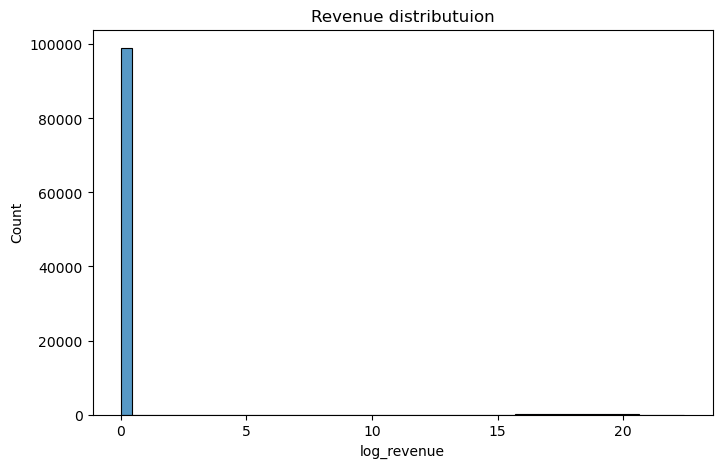

In [ ]:
plt.figure(figsize=(3,3))
sns.histplot(df['log_revenue'],bins=50)
plt.title("Revenue distributuion")
plt.show()

In [ ]:
df.head()

,channelGrouping,date,visitNumber,visitStartTime,browser,operatingSystem,operatingSystemVersion,isMobile,mobileDeviceBranding,language,...,newVisits,timeOnSite,transactions,transactionRevenue,campaign,source,medium,keyword,isTrueDirect,log_revenue
0,Organic Search,20171016,1,1508198450,Firefox,Windows,not available in demo dataset,False,not available in demo dataset,not available in demo dataset,...,1,0,0,0.0,(not set),google,organic,water bottle,unknown,0.0
1,Referral,20171016,6,1508176307,Chrome,Chrome OS,not available in demo dataset,False,not available in demo dataset,not available in demo dataset,...,0,28,0,0.0,(not set),sites.google.com,referral,unknown,unknown,0.0
2,Direct,20171016,1,1508201613,Chrome,Android,not available in demo dataset,True,not available in demo dataset,not available in demo dataset,...,1,38,0,0.0,(not set),(direct),(none),unknown,True,0.0
3,Organic Search,20171016,1,1508169851,Chrome,Windows,not available in demo dataset,False,not available in demo dataset,not available in demo dataset,...,1,1,0,0.0,(not set),google,organic,(not provided),unknown,0.0
4,Organic Search,20171016,1,1508190552,Chrome,Windows,not available in demo dataset,False,not available in demo dataset,not available in demo dataset,...,1,52,0,0.0,(not set),google,organic,(not provided),unknown,0.0


In [ ]:
df['browser'].unique()

array(['Firefox', 'Chrome', 'Safari', 'UC Browser', 'Internet Explorer',
       'Edge', 'Samsung Internet', 'Android Webview', 'Safari (in-app)',
       'Opera Mini', 'Opera', 'YaBrowser', 'Amazon Silk',
       'Mozilla Compatible Agent', 'Puffin', 'Maxthon', 'BlackBerry',
       'ADM', 'Coc Coc', 'MRCHROME', 'Android Browser',
       'Playstation Vita Browser', 'Nintendo Browser', 'Nokia Browser',
       'SeaMonkey', 'Lunascape', 'IE with Chrome Frame', 'ThumbSniper',
       'LYF_LS_4002_12', 'DESKTOP', 'Mozilla', 'Browser',
       'osee2unifiedRelease', 'Seznam', '(not set)'], dtype=object)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 33 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   channelGrouping         100000 non-null  object 
 1   date                    100000 non-null  int64  
 2   visitNumber             100000 non-null  int64  
 3   visitStartTime          100000 non-null  int64  
 4   browser                 100000 non-null  object 
 5   operatingSystem         100000 non-null  object 
 6   operatingSystemVersion  100000 non-null  object 
 7   isMobile                100000 non-null  bool   
 8   mobileDeviceBranding    100000 non-null  object 
 9   language                100000 non-null  object 
 10  screenResolution        100000 non-null  object 
 11  deviceCategory          100000 non-null  object 
 12  continent               100000 non-null  object 
 13  subContinent            100000 non-null  object 
 14  country              

feature engineering


In [ ]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
for col in df.columns:
    if df[col].dtype=='object':
        df[col]=le.fit_transform(df[col].astype(str))

In [ ]:
print(df)

       channelGrouping      date  visitNumber  visitStartTime  browser  \
0                    4  20171016            1      1508198450       11   
1                    6  20171016            6      1508176307        7   
2                    2  20171016            1      1508201613        7   
3                    4  20171016            1      1508169851        7   
4                    4  20171016            1      1508190552        7   
...                ...       ...          ...             ...      ...   
99995                2  20170529            1      1496122172        7   
99996                6  20170529           22      1496087028        7   
99997                4  20170529            2      1496112576        7   
99998                7  20170529            2      1496120385       13   
99999                4  20170529            1      1496073409        7   

       operatingSystem  operatingSystemVersion  isMobile  \
0                   14                       0     

In [ ]:
df.dtypes

channelGrouping             int64
date                        int64
visitNumber                 int64
visitStartTime              int64
browser                     int64
operatingSystem             int64
operatingSystemVersion      int64
isMobile                     bool
mobileDeviceBranding        int64
language                    int64
screenResolution            int64
deviceCategory              int64
continent                   int64
subContinent                int64
country                     int64
region                      int64
metro                       int64
city                        int64
networkDomain               int64
visits                      int64
hits                        int64
pageviews                   int64
bounces                     int64
newVisits                   int64
timeOnSite                  int64
transactions                int64
transactionRevenue        float64
campaign                    int64
source                      int64
medium        

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 33 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   channelGrouping         100000 non-null  int64  
 1   date                    100000 non-null  int64  
 2   visitNumber             100000 non-null  int64  
 3   visitStartTime          100000 non-null  int64  
 4   browser                 100000 non-null  int64  
 5   operatingSystem         100000 non-null  int64  
 6   operatingSystemVersion  100000 non-null  int64  
 7   isMobile                100000 non-null  bool   
 8   mobileDeviceBranding    100000 non-null  int64  
 9   language                100000 non-null  int64  
 10  screenResolution        100000 non-null  int64  
 11  deviceCategory          100000 non-null  int64  
 12  continent               100000 non-null  int64  
 13  subContinent            100000 non-null  int64  
 14  country              

FEATURES AND THE TARGET

X -> features
y->target

In [ ]:
X=df.drop(['transactionRevenue','log_revenue'], axis=1)
y=df['log_revenue']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
X_train.shape,X_test.shape,y_train.shape,y_test.shape

((80000, 31), (20000, 31), (80000,), (20000,))

fit-----learn 



transform----aplly

In [ ]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
X_train_scaled=sc.fit_transform(X_train)
X_test_scaled=sc.transform(X_test)


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score

LINEAR REGRESSION

In [ ]:
lr=LinearRegression()
lr.fit(X_train_scaled,y_train)
y_pred_lr=lr.predict(X_test_scaled)

In [ ]:
print("Linear Regression resuls")
print("mean_squarted_error",mean_squared_error(y_pred_lr,y_test))
print("mean_absolute_error",mean_absolute_error(y_pred_lr,y_test))
print("r2 score",r2_score(y_test,y_pred_lr))

Linear Regression resuls
mean_squarted_error 0.232772640637515
mean_absolute_error 0.05425662187516948
r2 score 0.9243237901629882


Low MAE
Low RMSE
High R²

In [ ]:
dt=DecisionTreeRegressor(random_state=42)
dt.fit(X_train,y_train)
y_pred_dt=dt.predict(X_test)
print("decisontreeregressior  resuls")
print("mean_squarted_error",mean_squared_error(y_pred_dt,y_test))
print("mean_absolute_error",mean_absolute_error(y_pred_dt,y_test))
print("r2 score",r2_score(y_test,y_pred_dt))

decisontreeregressior  resuls
mean_squarted_error 0.06865126829045226
mean_absolute_error 0.014593540226520622
r2 score 0.977680934621455


DECISION TREE WITH PARAMETERS BECAUSE OF THE OVERFITITING

In [ ]:
dt2 = DecisionTreeRegressor(
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)
dt2.fit(X_train,y_train)

y_pred_dt2 = dt2.predict(X_test)

print("Decision Tree Results")

print("MSE:",mean_squared_error(y_test,y_pred_dt2))
print("MAE:",mean_absolute_error(y_test,y_pred_dt2))
print("R2:",r2_score(y_test,y_pred_dt2))

Decision Tree Results
MSE: 0.04461924567367183
MAE: 0.010227670199724
R2: 0.9854939335261991


RANDOMFOREST REDUCES THE OVERFITTING BY USING THE MUMLTIPLE TREES AND USING THE RANDOM FOREST SUBSETS  AND AVERAGEING PREDICTIONS

In [ ]:
rf=RandomForestRegressor(n_estimators=200,random_state=42)
rf.fit(X_train,y_train)
y_pred_rf=rf.predict(X_test)
print("Random Forest Results")

print("MSE:",mean_squared_error(y_test,y_pred_rf))
print("MAE:",mean_absolute_error(y_test,y_pred_rf))
print("R2:",r2_score(y_test,y_pred_rf))


Random Forest Results
MSE: 0.041794560585671346
MAE: 0.009665796595938242
R2: 0.986412260786901


In [ ]:
gb=GradientBoostingRegressor(random_state=42)


gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_test)

print("Gradient Boosting Results")

print("MSE:", mean_squared_error(y_test, y_pred_gb))
print("MAE:", mean_absolute_error(y_test, y_pred_gb))
print("R2:", r2_score(y_test, y_pred_gb))

Gradient Boosting Results
MSE: 0.05018703401026532
MAE: 0.010717801560937162
R2: 0.9836838019001878


In [ ]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [ ]:
from xgboost import XGBRegressor
xgb=XGBRegressor(random_state=42,n_estimators=200,learning_rate=0.1,max_depth=6)
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

print("XGBoost Results")

print("MSE:", mean_squared_error(y_test, y_pred_xgb))
print("MAE:", mean_absolute_error(y_test, y_pred_xgb))
print("R2:", r2_score(y_test, y_pred_xgb))


XGBoost Results
MSE: 0.03605067712957714
MAE: 0.0098810007622007
R2: 0.9882796423164151


In [ ]:

pip install lightgbm

Note: you may need to restart the kernel to use updated packages.


In [ ]:
pip install lightgbm

Note: you may need to restart the kernel to use updated packages.


In [ ]:
from lightgbm import LGBMRegressor
model=LGBMRegressor()
model.fit(X_train,y_train)
y_pred_lgb=model.predict(X_test)
print("LGBMRegressor Results")

print("MSE:", mean_squared_error(y_test, y_pred_lgb))
print("MAE:", mean_absolute_error(y_test, y_pred_lgb))
print("R2:", r2_score(y_test, y_pred_lgb))

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006391 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2141
[LightGBM] [Info] Number of data points in the train set: 80000, number of used features: 26
[LightGBM] [Info] Start training from score 0.177960
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
LGBMRegressor Results
MSE: 0.04080490786583476
MAE: 0.010501180042617882
R2: 0.9867340046425663


In [ ]:
X=X.drop(columns=['transactions'])

In [ ]:
from sklearn.model_selection import cross_val_score

In [ ]:
from sklearn.linear_model import LinearRegression

lr=LinearRegression()
scores_lr=cross_val_score(lr,X,y,cv=5,scoring="r2",n_jobs=-1)
print("Linear regression cv scores:",scores_lr)
print("average r2",scores_lr)
print("average r2",scores_lr.mean())

Linear regression cv scores: [0.03105358 0.03869905 0.0252136  0.03910087 0.01441947]
average r2 [0.03105358 0.03869905 0.0252136  0.03910087 0.01441947]
average r2 0.029697313554685432


In [ ]:
from sklearn.tree import DecisionTreeRegressor
dt=DecisionTreeRegressor()

scores_dt=cross_val_score(dt,X,y,cv=5,scoring="r2",n_jobs=-1)
print("decsion tree Cv scores:",scores_dt)
print("averge r2",scores_dt)
print("average r2",scores_dt.mean())

decsion tree Cv scores: [-0.55411311 -0.73646083 -0.48659052 -0.22852131 -0.60847371]
averge r2 [-0.55411311 -0.73646083 -0.48659052 -0.22852131 -0.60847371]
average r2 -0.5228318975072679


In [ ]:
rf=RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)
scores_rf=cross_val_score(rf,X,y,cv=5,scoring="r2",n_jobs=-1)
print("Random forest cv scores:",scores_rf)
print("average r2:",scores_rf)
print("average r2:",scores_rf.mean())


Random forest cv scores: [0.16930356 0.16209445 0.22658385 0.29379543 0.17110202]
average r2: [0.16930356 0.16209445 0.22658385 0.29379543 0.17110202]
average r2: 0.20457586291023575


In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

gb = GradientBoostingRegressor(random_state=42)

scores_gb = cross_val_score(
    gb,
    X,
    y,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

print("Gradient Boosting CV Scores:", scores_gb)
print("average r2:",scores_gb)
print("Average R2:", scores_gb.mean())

Gradient Boosting CV Scores: [0.18671035 0.20735795 0.19828716 0.2070606  0.18993599]
average r2: [0.18671035 0.20735795 0.19828716 0.2070606  0.18993599]
Average R2: 0.19787040821168564


In [ ]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)

scores_xgb = cross_val_score(
    xgb,
    X,
    y,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

print("XGBoost CV Scores:", scores_xgb)
print("average r2:",scores_xgb)
print("Average R2:", scores_xgb.mean())

XGBoost CV Scores: [0.1997692  0.24218276 0.2494358  0.30233619 0.20941175]
average r2: [0.1997692  0.24218276 0.2494358  0.30233619 0.20941175]
Average R2: 0.24062713991491796


In [ ]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)

scores_xgb = cross_val_score(
    xgb,
    X,
    y,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

print("XGBoost CV Scores:", scores_xgb)
print("Average R2:", scores_xgb.mean())
print("average r2:",scores_xgb)

XGBoost CV Scores: [0.1997692  0.24218276 0.2494358  0.30233619 0.20941175]
Average R2: 0.24062713991491796
average r2: [0.1997692  0.24218276 0.2494358  0.30233619 0.20941175]


In [ ]:
from lightgbm import LGBMRegressor

lgb = LGBMRegressor(
    n_estimators=200,
    learning_rate=0.1,
    random_state=42
)

scores_lgb = cross_val_score(
    lgb,
    X,
    y,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

print("LightGBM CV Scores:", scores_lgb)
print("Average R2:", scores_lgb.mean())
print("Average R2:", scores_lgb)

LightGBM CV Scores: [0.21140551 0.24657849 0.25019157 0.31688182 0.19733554]
Average R2: 0.244478585128887
Average R2: [0.21140551 0.24657849 0.25019157 0.31688182 0.19733554]


In [ ]:
X

,channelGrouping,date,visitNumber,visitStartTime,browser,operatingSystem,operatingSystemVersion,isMobile,mobileDeviceBranding,language,...,hits,pageviews,bounces,newVisits,timeOnSite,campaign,source,medium,keyword,isTrueDirect
0,4,20171016,1,1508198450,11,14,0,False,0,0,...,0,1,1,1,0,3,42,5,265,1
1,6,20171016,6,1508176307,7,3,0,False,0,0,...,54,34,0,0,1408,3,124,6,264,1
2,2,20171016,1,1508201613,7,1,0,True,0,0,...,54,34,0,1,1650,3,0,0,264,0
3,4,20171016,1,1508169851,7,14,0,False,0,0,...,54,34,0,1,1,3,42,5,4,1
4,4,20171016,1,1508190552,7,14,0,False,0,0,...,54,34,0,1,1864,3,42,5,4,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,2,20170529,1,1496122172,7,14,0,False,0,0,...,29,2,0,1,707,3,0,0,264,0
99996,6,20170529,22,1496087028,7,3,0,False,0,0,...,38,18,0,0,1302,3,0,0,264,0
99997,4,20170529,2,1496112576,7,3,0,False,0,0,...,38,25,0,0,1617,3,42,5,4,0
99998,7,20170529,2,1496120385,13,14,0,False,0,0,...,38,21,0,0,1742,3,36,6,264,0
